# Filtros clasicos 

Este notebook usa la imagen `data/cnn_images/leonora.png` para mostrar como funcionan filtros de convolucion clasicos.

## 1. Cargar imagen

Ruta: ..\data\cnn_images\leonora.png
Shape RGB: (1945, 1960, 3)


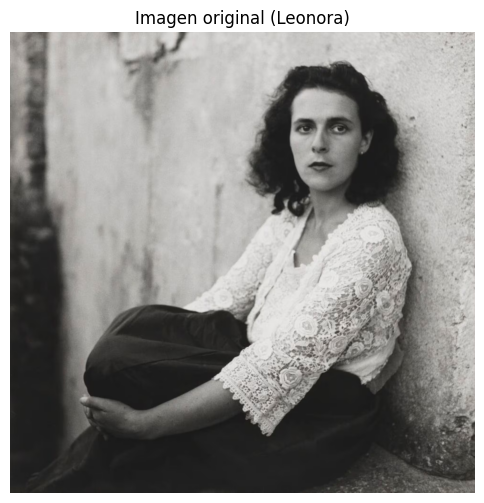

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img_path = Path('../data/cnn_images/leonora.png')
if not img_path.exists():
    raise FileNotFoundError(f'No se encontro la imagen en: {img_path.resolve()}')

img = Image.open(img_path).convert('RGB')
img_np = np.array(img).astype(np.float32) / 255.0
gray = img_np.mean(axis=2)

print('Ruta:', img_path)
print('Shape RGB:', img_np.shape)

plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.title('Imagen original (Leonora)')
plt.axis('off')
plt.show()

## 2. Funcion de convolucion 2D 

In [3]:
def convolve2d_single_channel(channel: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    padded = np.pad(channel, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    out = np.zeros_like(channel, dtype=np.float32)

    # Convolucion directa para que se vea claramente el proceso
    for i in range(channel.shape[0]):
        for j in range(channel.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel)

    return out


def apply_filter_rgb(image_rgb: np.ndarray, kernel: np.ndarray, normalize=False) -> np.ndarray:
    out_channels = []
    for c in range(3):
        out_channels.append(convolve2d_single_channel(image_rgb[:, :, c], kernel))
    out = np.stack(out_channels, axis=2)

    if normalize:
        vmin, vmax = out.min(), out.max()
        out = (out - vmin) / (vmax - vmin + 1e-8)

    return np.clip(out, 0.0, 1.0)


def apply_filter_gray(image_gray: np.ndarray, kernel: np.ndarray, normalize=False) -> np.ndarray:
    out = convolve2d_single_channel(image_gray, kernel)
    if normalize:
        vmin, vmax = out.min(), out.max()
        out = (out - vmin) / (vmax - vmin + 1e-8)
    return np.clip(out, 0.0, 1.0)

## 3. Definir kernels clasicos

In [7]:
kernels = {
    'Identity': np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]], dtype=np.float32),
    'Box blur': (1/25) * np.ones((5, 5), dtype=np.float32),
    'Gaussian blur': (1/256) * np.array(
        [[1, 4, 6, 4, 1],
         [4, 16, 24, 16, 4],
         [6, 24, 36, 24, 6],
         [4, 16, 24, 16, 4],
         [1, 4, 6, 4, 1]], dtype=np.float32
    ),
    'Sharpen': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32),
    'Edge (Laplacian)': np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype=np.float32),
    'Emboss': np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]], dtype=np.float32),
    'Sobel X': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32),
    'Sobel Y': np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32),
}

for name, k in kernels.items():
    print(f'{name:18s} shape={k.shape} sum={k.sum():.3f}')

Identity           shape=(3, 3) sum=1.000
Box blur           shape=(5, 5) sum=1.000
Gaussian blur      shape=(5, 5) sum=1.000
Sharpen            shape=(3, 3) sum=1.000
Edge (Laplacian)   shape=(3, 3) sum=0.000
Emboss             shape=(3, 3) sum=1.000
Sobel X            shape=(3, 3) sum=0.000
Sobel Y            shape=(3, 3) sum=0.000


## 4. Visualizar resultados en RGB

Guardada: ..\data\cnn_images\leonora_identity.png
Guardada: ..\data\cnn_images\leonora_box_blur.png
Guardada: ..\data\cnn_images\leonora_gaussian_blur.png
Guardada: ..\data\cnn_images\leonora_sharpen.png
Guardada: ..\data\cnn_images\leonora_edge_laplacian.png
Guardada: ..\data\cnn_images\leonora_emboss.png
Guardada: ..\data\cnn_images\leonora_sobel_x.png
Guardada: ..\data\cnn_images\leonora_sobel_y.png


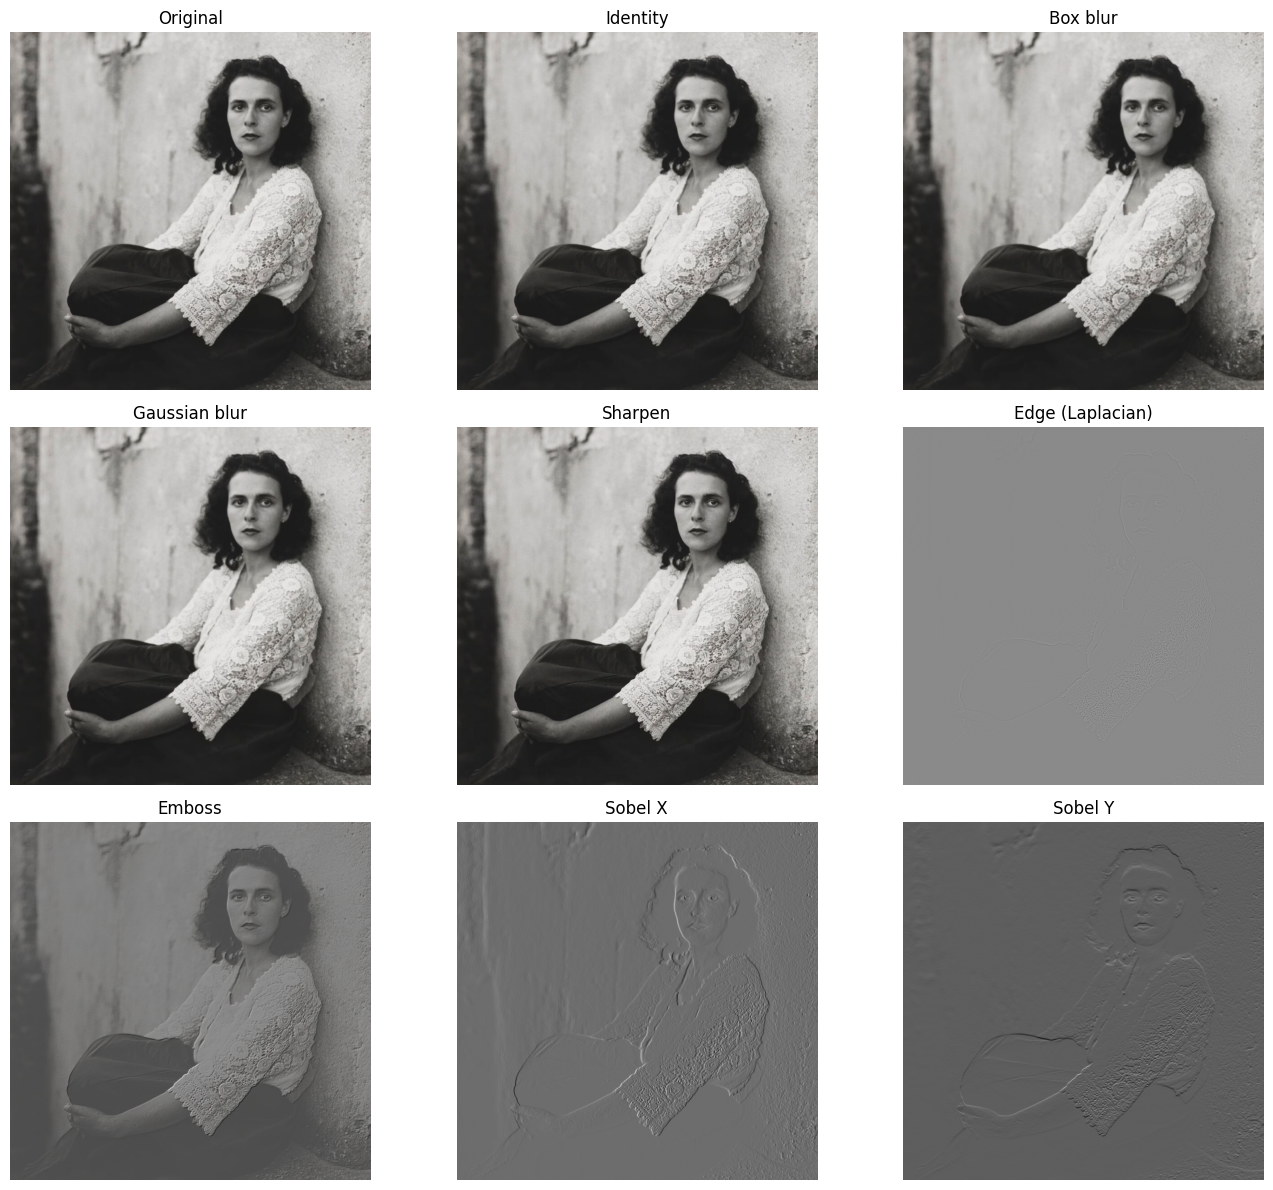

In [8]:
results_rgb = {}
for name, kernel in kernels.items():
    normalize = name in {'Edge (Laplacian)', 'Sobel X', 'Sobel Y', 'Emboss'}
    results_rgb[name] = apply_filter_rgb(img_np, kernel, normalize=normalize)

# Guardar la imagen original y cada filtro por separado en la misma carpeta de la imagen fuente
output_dir = img_path.parent
base_name = img_path.stem
plt.imsave(output_dir / f'{base_name}_original.png', np.clip(img_np, 0.0, 1.0))

for name, out in results_rgb.items():
    safe_name = ''.join(ch.lower() if ch.isalnum() else '_' for ch in name)
    safe_name = '_'.join(part for part in safe_name.split('_') if part)
    out_path = output_dir / f'{base_name}_{safe_name}.png'
    plt.imsave(out_path, np.clip(out, 0.0, 1.0))
    print(f'Guardada: {out_path}')

n = len(results_rgb) + 1
cols = 3
rows = int(np.ceil(n / cols))

plt.figure(figsize=(14, 4 * rows))

plt.subplot(rows, cols, 1)
plt.imshow(img_np)
plt.title('Original')
plt.axis('off')

for idx, (name, out) in enumerate(results_rgb.items(), start=2):
    plt.subplot(rows, cols, idx)
    plt.imshow(out)
    plt.title(name)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Idea clave

- Aqui usamos kernels definidos a mano.
- En una CNN real, los kernels (pesos) se aprenden automaticamente con backpropagation.
- En capas iniciales, muchos filtros aprendidos se parecen a detectores de bordes o texturas, como los que viste arriba.